<div align="center">

# Train a SLM with a BPE Tokenizer

## TRI AI Saturdays Cohort 10 - Lab Session
### Wednesday, July 8, 2026 | 7:00 - 9:00 PM WAT

**In partnership with Google DeepMind**

**Instructor: Kaletsidik Ayalew**

</div>

## Lab Overview

Welcome! In this session we will build a **Small Language Model (SLM)** from scratch. 

**What we'll do:**
1. Use a **BPE tokenizer** to convert text into numbers (you already know BPE from last session!)
2. Create **training data** using a sliding window
3. Build a **tiny Transformer** in PyTorch
4. **Train** it and watch the loss drop
5. **Generate text** â€” your first AI that can write!

> **Tip:** No prior ML experience needed. Just Python basics and curiosity.

## Setup & Imports

In [15]:
# Install if needed:
# !pip install tiktoken -q
# !pip install torch numpy matplotlib

import re, math
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.nn import functional as F
import tiktoken

# Check for GPU (free in Google Colab)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on: {device.upper()}")

print("Setup complete!")

Running on: CPU
Setup complete!


---
## Part 1: Quick BPE Recap

You already learned BPE last session! Here are the core functions we'll reuse. 

**Quick reminder:** BPE starts with characters and merges the most frequent adjacent pairs until we reach a target vocabulary size.

In [16]:
# BPE from scratch â€” you've seen these before!

def get_vocab(corpus):
    vocab = {}
    for word in corpus.lower().split():
        tokenized = ' '.join(list(word)) + ' </w>'
        vocab[tokenized] = vocab.get(tokenized, 0) + 1
    return vocab

def get_stats(vocab):
    pairs = defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i + 1])] += freq
    return pairs

def merge_vocab(pair, vocab):
    a, b = pair
    merged = a + b.replace('</w>', '')
    pattern = ' '.join([a, b])
    new_vocab = {}
    for word, freq in vocab.items():
        new_vocab[word.replace(pattern, merged)] = freq
    return new_vocab

def bpe_train(corpus, vocab_size, verbose=True):
    vocab = get_vocab(corpus)
    initial_size = len(set(' '.join(vocab.keys()).split()))
    num_merges = vocab_size - initial_size
    merges = []
    if verbose:
        print(f'Initial symbols: {initial_size}, Target: {vocab_size}')
    for i in range(num_merges):
        pairs = get_stats(vocab)
        if not pairs:
            break
        best = max(pairs, key=pairs.get)
        vocab = merge_vocab(best, vocab)
        merges.append(best)
        if verbose and (i < 5 or (i+1) % 10 == 0):
            print(f'  Merge {i+1}: "{best[0]}" + "{best[1]}" -> "{best[0]+best[1]}"')
    if verbose:
        print(f'Done. {len(merges)} merges performed.')
    return merges, vocab, initial_size

def tokenize_bpe(text, merges):
    words = text.lower().split()
    tokens = []
    for word in words:
        symbols = list(word) + ['</w>']
        for a, b in merges:
            i = 0
            while i < len(symbols) - 1:
                if symbols[i] == a and symbols[i+1] == b:
                    symbols = symbols[:i] + [a+b] + symbols[i+2:]
                else:
                    i += 1
        tokens.extend(symbols[:-1])
    return tokens

print('BPE functions loaded!')

BPE functions loaded!


### Train BPE on a Simple Corpus

Let's train BPE on a tiny text about everyday life â€” school, house, studying. These are words you use every day!

In [17]:
CORPUS = (
    'I study hard at school every day. '
    'My house is near the school. '
    'I have a theory about how to study better. '
    'The theory of learning is interesting. '
    'School is where we study theory and practice. '
    'Practice makes perfect at school. '
    'I go home after school to study more. '
    'My friend studies theory at home. '
    'Learning at school is fun and useful. '
    'Theory without practice is just theory.'
)

print('Corpus:', len(CORPUS.split()), 'words')

# Train custom BPE (50 tokens)
merges, final_vocab, initial_size = bpe_train(CORPUS, vocab_size=50, verbose=True)

Corpus: 68 words
Initial symbols: 25, Target: 50
  Merge 1: "y" + "</w>" -> "y</w>"
  Merge 2: "h" + "o" -> "ho"
  Merge 3: "." + "</w>" -> ".</w>"
  Merge 4: "e" + "</w>" -> "e</w>"
  Merge 5: "h" + "e" -> "he"
  Merge 10: "s" + "</w>" -> "s</w>"
  Merge 20: "stud" + "y" -> "study"
Done. 25 merges performed.


In [18]:
# Test our tokenizer on a new sentence
test = 'I study theory at school today'
tokens = tokenize_bpe(test, merges)
print(f'Original: "{test}"')
print(f'Tokens:   {tokens}')

Original: "I study theory at school today"
Tokens:   ['i', 'stud', 'theo', 'r', 'a', 't', 'o', 'd', 'a']


---
## Part 2: Switch to a Production Tokenizer (tiktoken)

Our custom BPE works, but it only has 50 tokens. Real LLMs use **100,000+ tokens**. 

Let's use `tiktoken` â€” the same tokenizer that powers **GPT-4**!

In [19]:
# Load the GPT-4 tokenizer (~100K tokens)
enc = tiktoken.get_encoding('cl100k_base')

# Our tiny story for training the SLM
raw_text = '''
Jide was hungry so she went looking for food.
She checked the market, but it was closed.
Then, she found a small cafe and ordered some rice and water.
She was very happy to finally eat!
'''

# Convert text to token IDs (numbers the model can understand)
data = torch.tensor(enc.encode(raw_text), dtype=torch.long)

print(f'Our text has {len(raw_text)} characters, which becomes {len(data)} tokens.')
print(f'First 10 token IDs: {data[:10].tolist()}')

# Decode a token back to text (proof it works)
sample = data[0].item()
print(f'Token ID {sample} decodes back to: "{enc.decode([sample])}"')

Our text has 187 characters, which becomes 44 tokens.
First 10 token IDs: [198, 41, 579, 574, 30056, 779, 1364, 4024, 3411, 369]
Token ID 198 decodes back to: "
"


### Why does this matter?

With **tiktoken**:
- 'Jide' = 1 token (it knows it's a name)
- 'hungry' = 1 token
- 'market' = 1 token

With our custom 50-token BPE, every word would be split into 3-5 pieces. The model would have to learn to recombine them â€” wasting brain power!

---
## Part 3: Creating Training Data (The Sliding Window)

A language model's only job is **predict the next token**. 

To train it, we make thousands of "flashcards":
- **Front:** A sequence of tokens (the context)
- **Back:** The very next token (the target)

In [20]:
block_size = 8   # How many tokens the model looks at (context window)
batch_size = 4   # How many examples we process at once

def get_batch():
    # Pick random starting points in our data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    # x = context (8 tokens)
    x = torch.stack([data[i:i+block_size] for i in ix])
    # y = target (the next token after each position)
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch()

print('Here is ONE training example:')
print()
for i in range(block_size):
    ctx = enc.decode(xb[0][:i+1].tolist())
    tgt = enc.decode([yb[0][i].item()])
    print(f'Context: "{ctx:30s}"  -->  Target: "{tgt}"')

Here is ONE training example:

Context: "Then                          "  -->  Target: ","
Context: "Then,                         "  -->  Target: " she"
Context: "Then, she                     "  -->  Target: " found"
Context: "Then, she found               "  -->  Target: " a"
Context: "Then, she found a             "  -->  Target: " small"
Context: "Then, she found a small       "  -->  Target: " cafe"
Context: "Then, she found a small cafe  "  -->  Target: " and"
Context: "Then, she found a small cafe and"  -->  Target: " ordered"


**See what's happening?** At position 0, the model sees "Jide" and must predict " was". At position 1, it sees "Jide was" and must predict " hungry". And so on.

Each sentence creates **block_size** different flashcards. Our tiny story creates dozens of training examples!

---
## Part 4: The Tiny SLM Architecture

Now we build the brain! This is a miniature version of what powers ChatGPT.

**Three main parts:**
1. **Token Embedding** â€” Each token ID â†’ a vector of 32 numbers.
2. **Position Embedding** â€” Each position (1st, 2nd, 3rd...) â†’ a vector, so the model knows word order.
3. **Linear Head** â€” Predicts which token comes next.

In [21]:
class TinySLM(nn.Module):
    def __init__(self, vocab_size, n_embd):
        super().__init__()
        # Maps each token ID to a vector (like a dictionary of meanings)
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # Maps each position to a vector (so the model knows word order)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        # Predicts next token from the embedding
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        # idx shape: (batch, block_size) â€” our context
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)                    # (B, T, embed)
        pos_emb = self.position_embedding_table(
            torch.arange(T, device=device))                           # (T, embed)
        x = tok_emb + pos_emb                                        # (B, T, embed)
        logits = self.lm_head(x)                                     # (B, T, vocab)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=1.0):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

# Create our model (~6.5M params)
vocab_size = enc.n_vocab  # ~100K tokens (tiktoken)
model = TinySLM(vocab_size, n_embd=32).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model created! Total parameters: {total_params:,}')
print('(GPT-4 has ~1.7 trillion parameters for comparison)')

Model created! Total parameters: 6,518,005
(GPT-4 has ~1.7 trillion parameters for comparison)


---
## Part 5: Training (Becoming Less Wrong)

A fresh model guesses randomly. Training fixes that:
1. **Forward pass** â€” Make a prediction, calculate the loss
2. **Backward pass** â€” Figure out how to adjust each weight
3. **Update** â€” Nudge the weights to be slightly less wrong

In [22]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

training_steps = 600
losses = []

print('Starting training...')
print()

for step in range(training_steps):
    # Grab a random batch
    xb, yb = get_batch()
    # Forward pass
    logits, loss = model(xb, yb)
    # Backward pass
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    # Update weights
    optimizer.step()
    # Track progress
    losses.append(loss.item())
    if step % 100 == 0:
        print(f'  Step {step:4d} | Loss: {loss.item():.4f}')

print(f'\nFinal step {training_steps} | Loss: {loss.item():.4f}')
print(f'Starting loss was ~10 (random guessing), final loss is {losses[-1]:.2f} (learning!)')

Starting training...

  Step    0 | Loss: 11.8063
  Step  100 | Loss: 9.3518
  Step  200 | Loss: 6.4768
  Step  300 | Loss: 3.0745
  Step  400 | Loss: 1.9613
  Step  500 | Loss: 0.6693

Final step 600 | Loss: 0.5945
Starting loss was ~10 (random guessing), final loss is 0.59 (learning!)


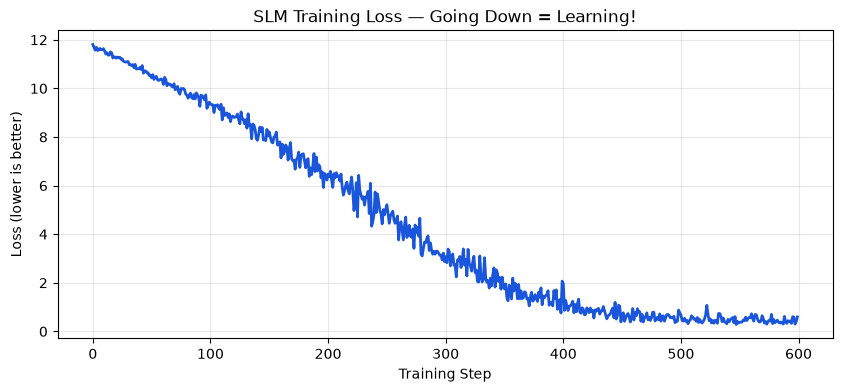

The loss dropped! Our model learned patterns from just 43 tokens!


In [23]:
# Plot the learning curve
plt.figure(figsize=(10, 4))
plt.plot(losses, color='#1a56db', linewidth=2)
plt.title('SLM Training Loss â€” Going Down = Learning!')
plt.xlabel('Training Step')
plt.ylabel('Loss (lower is better)')
plt.grid(alpha=0.3)
plt.show()
print('The loss dropped! Our model learned patterns from just 43 tokens!')

---
## Part 6: Let It Speak! (Text Generation)

The model has learned. Let's give it a starting word and see what it writes!

In [24]:
# Give the model a starting prompt
start_text = 'Jide was'
print(f'Prompt: "{start_text}"')
print()

# Encode the prompt into token IDs
context = torch.tensor([enc.encode(start_text)], dtype=torch.long, device=device)

# Generate 25 new tokens
generated = model.generate(context, max_new_tokens=25, temperature=0.8)

# Decode back to text
output = enc.decode(generated[0].tolist())

print('--- MODEL GENERATED TEXT ---')
print(output)
print('---------------------------')
print()
print('Try running this cell multiple times â€” you get different results!')
print('The model samples randomly, so every run is unique.')

Prompt: "Jide was"

--- MODEL GENERATED TEXT ---
Jide was closed.
She was hungry so she found a small cafe and water '+ Access nuestros_FIRST bend consegu measurements Median DS OfficeNationalexecute
---------------------------

Try running this cell multiple times â€” you get different results!
The model samples randomly, so every run is unique.


**Note:** The output might look a bit messy or repeat itself — that is expected! Our model has no attention mechanism (only embeddings + linear layer). It cannot track what it already wrote, so it tends to loop on learned patterns.

We added **position embeddings** so the model knows token order, and a **temperature** parameter. Lower temperature (< 1.0) = more focused but repetitive. Higher temperature (> 1.0) = more creative but messy. Try changing it in the generate call like model.generate(context, 25, temperature=0.8)!

---
## Part 7: Making Our Model Smarter

Let's upgrade 3 things and watch the improvement:

Bigger model has 12,935,733 parameters
Training bigger model...
  Step    0 | Loss: 11.5640
  Step  400 | Loss: 0.2906
  Step  800 | Loss: 0.2691
  Step 1200 | Loss: 0.2657
  Step 1600 | Loss: 0.2720

Final loss: 0.2517


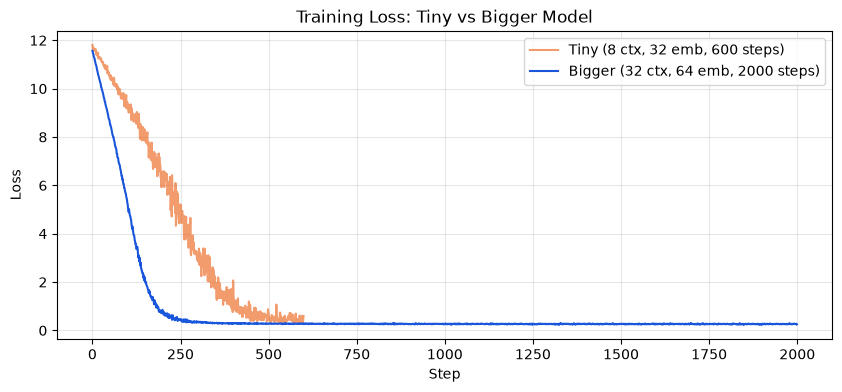

In [25]:
# Upgrade: bigger context, richer embeddings, more training
BIG_BLOCK  = 32     # Was 8  â€” sees more of the story
BIG_EMBD   = 64     # Was 32 â€” richer token meanings
BIG_STEPS  = 2000   # Was 600 â€” more practice

class BiggerSLM(nn.Module):
    def __init__(self, vocab_size, n_embd):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(BIG_BLOCK, n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(
            torch.arange(T, device=device))
        x = tok_emb + pos_emb
        logits = self.lm_head(x)
        if targets is None:
            return logits, None
        B, T, C = logits.shape
        logits = logits.view(B * T, C)
        targets = targets.view(B * T)
        loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=1.0):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -BIG_BLOCK:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx
# Create the bigger model
big_model = BiggerSLM(vocab_size, n_embd=BIG_EMBD).to(device)
print(f'Bigger model has {sum(p.numel() for p in big_model.parameters()):,} parameters')

# We need a new get_batch that uses BIG_BLOCK
def get_big_batch():
    ix = torch.randint(len(data) - BIG_BLOCK, (batch_size,))
    x = torch.stack([data[i:i+BIG_BLOCK] for i in ix])
    y = torch.stack([data[i+1:i+BIG_BLOCK+1] for i in ix])
    return x.to(device), y.to(device)

# Train
optimizer = torch.optim.AdamW(big_model.parameters(), lr=1e-3)
big_losses = []

print('Training bigger model...')
for step in range(BIG_STEPS):
    xb, yb = get_big_batch()
    logits, loss = big_model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    big_losses.append(loss.item())
    if step % 400 == 0:
        print(f'  Step {step:4d} | Loss: {loss.item():.4f}')

print(f'\nFinal loss: {loss.item():.4f}')

# Plot comparison
plt.figure(figsize=(10, 4))
plt.plot(losses, label='Tiny (8 ctx, 32 emb, 600 steps)', color='#ea580c', alpha=0.6)
plt.plot(big_losses, label='Bigger (32 ctx, 64 emb, 2000 steps)', color='#1a56db')
plt.title('Training Loss: Tiny vs Bigger Model')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [28]:
# Generate with the bigger model
context = torch.tensor([enc.encode('Jide was')], dtype=torch.long, device=device)
generated = big_model.generate(context, max_new_tokens=30, temperature=0.8)
output = enc.decode(generated[0].tolist())

print('--- BIGGER MODEL GENERATION ---')
print(output)
print('-------------------------------')
print()
print('Compare this with the tiny model output above!')
print('The bigger model usually produces more coherent text.')

AttributeError: 'tokenizers.Encoding' object has no attribute 'encode'

---
## Bonus: Hugging Face BPE Tokenizer

For reference, here's how to train a BPE tokenizer using the Hugging Face `tokenizers` library (Rust-based, production-ready).

In [27]:
# Hugging Face tokenizers (pip install tokenizers)
try:
    from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders
    
    # Create and train a BPE tokenizer
    hf_tokenizer = Tokenizer(models.BPE(unk_token='[UNK]'))
    hf_tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=True)
    
    trainer = trainers.BpeTrainer(
        vocab_size=200,
        min_frequency=1,
        special_tokens=['[UNK]', '[CLS]', '[SEP]', '[PAD]', '[MASK]']
    )
    
    hf_tokenizer.train_from_iterator([CORPUS + raw_text], trainer=trainer)
    hf_tokenizer.decoder = decoders.ByteLevel()
    
    print(f'Hugging Face tokenizer vocab size: {hf_tokenizer.get_vocab_size()}')
    
    # Test it
    test_sentences = [
        'I study theory at school',
        'Jide was hungry and went to the market'
    ]
    for s in test_sentences:
        enc = hf_tokenizer.encode(s)
        print(f'"{s}"')
        print(f'  Tokens: {enc.tokens}')
        print(f'  IDs:    {enc.ids[:10]}...')
        print()
        
except ImportError:
    print('Install tokenizers: !pip install tokenizers')

Hugging Face tokenizer vocab size: 200
"I study theory at school"
  Tokens: ['Ä I', 'Ä study', 'Ä theory', 'Ä at', 'Ä school']
  IDs:    [84, 74, 62, 70, 59]...

"Jide was hungry and went to the market"
  Tokens: ['Ä ', 'Ji', 'de', 'Ä was', 'Ä hun', 'gr', 'y', 'Ä and', 'Ä we', 'nt', 'Ä to', 'Ä the', 'Ä m', 'arket']
  IDs:    [39, 115, 125, 89, 188, 132, 37, 71, 106, 141]...



---
## Key Takeaways

1. **BPE Tokenizer** converts text to numbers â€” the first step for any language model.
2. **tiktoken** is a production-grade tokenizer with ~100K tokens (used by GPT-4).
3. **Sliding window** creates context â†’ target pairs for training.
4. **Even a tiny model** (32-dim embeddings) can learn patterns and generate text.
5. **Bigger context + richer embeddings + more training = better generation.**

---

**Next Session: Saturday, July 11 â€” Word Embeddings!**

---

*TRI AI Saturdays Cohort 10 | In partnership with Google DeepMind*

**Instructor:** Kaletsidik Ayalew | [GitHub](https://github.com/AlexKalll) | [Lab Repo](https://github.com/AlexKalll/tri-AI-Teaching)